# EDA 01: Model Master and Identity Spine

## Purpose

This notebook audits the two tables that determine which cell-line records can be joined and compared later. `identity_spine` is the stable model-level identity layer; `model_master` extends it with assay coverage, quality/context flags, and eligibility for the three proposed evidence routes: direct fusion, codependency, and conditional dependency.

The goal is not to predict gene pairs here. The goal is to establish a trustworthy denominator: which models exist, what cancer context they represent, which assays they have, and where missingness could bias later conclusions.

## Questions this notebook must answer

1. Is `model_id` unique and consistent between the two tables?
2. Which identity/context columns are incomplete or ambiguous?
3. Is assay coverage evenly distributed across cancer lineages, or would a pooled analysis be biased?
4. Which models qualify for each biological route, and what is excluded by missing data rather than biology?
5. Which context variables must be used for stratification or QC before we engineer gene-pair features?

**Interpretation rule:** a zero in an assay-availability flag means the assay is unavailable for that model. It does *not* mean the underlying biology is absent.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
MODEL_MASTER_PATH = PROJECT_ROOT / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv'
IDENTITY_SPINE_PATH = PROJECT_ROOT / 'data' / 'depmap_24Q4' / 'derived' / 'identity_spine.csv'

print(f'Project root: {PROJECT_ROOT}')
print(f'Model master: {MODEL_MASTER_PATH}')
print(f'Identity spine: {IDENTITY_SPINE_PATH}')

Project root: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25
Model master: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\architecture\model_master.csv
Identity spine: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25\data\depmap_24Q4\derived\identity_spine.csv


In [2]:
master = pd.read_csv(MODEL_MASTER_PATH, low_memory=False)
spine = pd.read_csv(IDENTITY_SPINE_PATH, low_memory=False)

display(Markdown(f'### Loaded {len(master):,} models from `model_master` and {len(spine):,} models from `identity_spine`'))
display(master.head(3))
display(spine.head(3))

### Loaded 2,105 models from `model_master` and 2,105 models from `identity_spine`

,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,sex,primary_or_metastasis,source_type,growth_pattern,ccle_name,rrid,n_profiles,n_rna_profiles,n_wes_profiles,n_wgs_profiles,default_rna_profile_id,default_dna_profile_id,has_default_rna,has_default_dna,has_expression,has_mutation_assay,has_any_mutation_event,has_fusion_assay,has_any_filtered_fusion_call,has_genomic_signatures,has_crispr_gene_effect,has_crispr_dependency,has_absolute_copy_number,has_model_condition,n_model_conditions,has_crispr_screen_qc,n_crispr_screens,has_crispr_efficacy,has_crispr_growth_rate,has_supplementary_metabolomics,has_supplementary_proteomics,has_supplementary_mirna,eligible_direct_fusion_route,eligible_codependency_route,eligible_conditional_dependency_route,release
0,ACH-000001,NIH:OVCAR-3,NIHOVCAR3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,Female,Metastatic,ATCC,Adherent,NIHOVCAR3_OVARY,CVCL_0465,3,1,1,1,PR-vFBZ2h,PR-sbeUkh,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,DepMap 24Q4 Public
1,ACH-000002,HL-60,HL60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,Female,Primary,ATCC,Suspension,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,CVCL_0002,2,1,1,0,PR-yEldOx,PR-qY1GC4,1,1,1,1,1,1,1,1,0,0,1,1,2,0,0,0,0,1,0,1,1,0,0,DepMap 24Q4 Public
2,ACH-000003,CACO2,CACO2,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,Male,Primary,ATCC,Adherent,CACO2_LARGE_INTESTINE,CVCL_0025,1,1,0,0,PR-jIbcm8,NaN,1,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,DepMap 24Q4 Public


,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,sex,primary_or_metastasis,source_type,growth_pattern,ccle_name,rrid,n_profiles,n_rna_profiles,n_wes_profiles,n_wgs_profiles,default_rna_profile_id,default_dna_profile_id,has_default_rna,has_default_dna
0,ACH-000001,NIH:OVCAR-3,NIHOVCAR3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,Female,Metastatic,ATCC,Adherent,NIHOVCAR3_OVARY,CVCL_0465,3,1,1,1,PR-vFBZ2h,PR-sbeUkh,1,1
1,ACH-000002,HL-60,HL60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,Female,Primary,ATCC,Suspension,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,CVCL_0002,2,1,1,0,PR-yEldOx,PR-qY1GC4,1,1
2,ACH-000003,CACO2,CACO2,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,Male,Primary,ATCC,Adherent,CACO2_LARGE_INTESTINE,CVCL_0025,1,1,0,0,PR-jIbcm8,NaN,1,0


## Column dictionary

### Identity spine and shared master columns

| Column | Meaning | Use in this project |
| --- | --- | --- |
| `model_id` | Stable DepMap identifier for one cancer model. | Only automatic model-level join key. |
| `cell_line_name` | Common cell-line name. | Human-readable reporting and manual review. |
| `stripped_cell_line_name` | Normalised cell-line label. | Cross-check only; it is not unique. |
| `oncotree_lineage` | Broad cancer/tissue lineage. | Main lineage-aware analysis stratum. |
| `oncotree_primary_disease` | Disease-level OncoTree diagnosis. | Finer disease cohort descriptions. |
| `oncotree_subtype` | Most specific available OncoTree subtype. | Use only where the cohort is large enough. |
| `sex` | Reported sex of the donor/model. | Descriptive covariate; relevant for sex-chromosome biology. |
| `primary_or_metastasis` | Primary, metastatic, recurrent, or unknown source. | Potential subgroup/confounder. |
| `source_type` | Cell-bank or source category. | Provenance and batch-like context. |
| `growth_pattern` | Adherent, suspension, or other culture behaviour. | Experimental-context covariate, not pair evidence. |
| `ccle_name` | CCLE-formatted cell-line name. | Cross-check for CCLE, PRISM, and supplementary omics. |
| `rrid` | Research Resource Identifier. | Manual identity/provenance verification. |
| `n_profiles` | Number of linked omics profiles. | Detects repeated or sparse profiling. |
| `n_rna_profiles` | Number of RNA profiles. | Audits expression-profile selection. |
| `n_wes_profiles` | Number of whole-exome profiles. | Audits mutation-profile selection. |
| `n_wgs_profiles` | Number of whole-genome profiles. | Audits genome-profile selection. |
| `default_rna_profile_id` | DepMap-selected RNA profile. | Safe route to profile-keyed RNA/fusion data. |
| `default_dna_profile_id` | DepMap-selected DNA profile. | Safe route to profile-keyed mutation data. |
| `has_default_rna` | Default RNA profile is available. | RNA/fusion eligibility context. |
| `has_default_dna` | Default DNA profile is available. | DNA analysis eligibility context. |

### Additional `model_master` assay coverage and route columns

| Column | Meaning | Use in this project |
| --- | --- | --- |
| `has_expression` | Selected RNA expression matrix covers the model. | Required for co-expression and expression plausibility. |
| `has_mutation_assay` | A suitable mutation profile exists. | Required for mutation-defined alteration cohorts. |
| `has_any_mutation_event` | At least one mapped mutation event is observed. | Mutation-burden descriptor; not a loss-of-function call. |
| `has_fusion_assay` | Fusion calling is available. | Denominator for fusion absence/presence. |
| `has_any_filtered_fusion_call` | At least one filtered fusion call exists. | General fusion evidence, not evidence for a queried pair. |
| `has_genomic_signatures` | Genomic signatures are available. | Instability and repair-context evidence. |
| `has_crispr_gene_effect` | CRISPR gene-effect values are available. | Essentiality and conditional-dependency features. |
| `has_crispr_dependency` | CRISPR dependency values are available. | Dependency and codependency features. |
| `has_absolute_copy_number` | Absolute copy number is available. | Deletion/amplification context. |
| `has_model_condition` | Condition metadata is available. | Flags culture/experimental context. |
| `n_model_conditions` | Number of recorded culture conditions. | Keeps repeated conditions visible. |
| `has_crispr_screen_qc` | Screen-level CRISPR QC is available. | Confidence context, not biology. |
| `n_crispr_screens` | Number of associated CRISPR screens. | Replication/context depth. |
| `has_crispr_efficacy` | CRISPR efficacy values are available. | Perturbation-confidence context. |
| `has_crispr_growth_rate` | Inferred growth-rate values are available. | Proliferation/context covariate. |
| `has_supplementary_metabolomics` | Older metabolomics maps to the model. | Supporting metabolic context only. |
| `has_supplementary_proteomics` | Proteomics maps to the model. | Supporting protein-level evidence only. |
| `has_supplementary_mirna` | miRNA data maps to the model. | Supporting regulatory context only. |
| `eligible_direct_fusion_route` | Model can contribute to direct fusion analysis. | Defines the fusion denominator. |
| `eligible_codependency_route` | Model can contribute to codependency analysis. | Defines the codependency denominator. |
| `eligible_conditional_dependency_route` | Model can support alteration-versus-dependency analysis. | Defines the conditional-dependency denominator. |
| `release` | DepMap release used to build the table. | Prevents accidental cross-release mixing. |


## 1. Basic data contract and schema audit

A master table must have exactly one row per model. We first check shape, types, missingness, uniqueness, and whether all binary flags really contain only 0/1 values.

In [4]:
def schema_audit(frame: pd.DataFrame, table_name: str) -> pd.DataFrame:
    return pd.DataFrame({
        'table': table_name,
        'column': frame.columns,
        'dtype': frame.dtypes.astype(str).values,
        'missing_n': frame.isna().sum().values,
        'missing_pct': (100 * frame.isna().mean()).round(2).values,
        'unique_n': frame.nunique(dropna=True).values,
    })

schema = pd.concat([schema_audit(spine, 'identity_spine'), schema_audit(master, 'model_master')], ignore_index=True)
display(schema)

binary_columns = [c for c in master.columns if c.startswith('has_') or c.startswith('eligible_')]
binary_value_audit = pd.DataFrame({
    'column': binary_columns,
    'observed_values': [sorted(master[c].dropna().unique().tolist()) for c in binary_columns],
    'is_binary_0_or_1': [set(master[c].dropna().unique()).issubset({0, 1}) for c in binary_columns],
})
display(binary_value_audit)
assert master['model_id'].is_unique, 'model_master must have one row per model_id'
assert spine['model_id'].is_unique, 'identity_spine must have one row per model_id'
assert binary_value_audit['is_binary_0_or_1'].all(), 'At least one availability flag is not binary'
print('PASS: primary keys are unique and all availability/eligibility flags are binary.')

,table,column,dtype,missing_n,missing_pct,unique_n
0,identity_spine,model_id,object,0,0.00,2105
1,identity_spine,cell_line_name,object,0,0.00,2105
2,identity_spine,stripped_cell_line_name,object,0,0.00,2104
3,identity_spine,oncotree_lineage,object,6,0.29,35
4,identity_spine,oncotree_primary_disease,object,0,0.00,96
5,identity_spine,oncotree_subtype,object,0,0.00,254
6,identity_spine,sex,object,23,1.09,3
7,identity_spine,primary_or_metastasis,object,344,16.34,4
8,identity_spine,source_type,object,36,1.71,22
9,identity_spine,growth_pattern,object,0,0.00,6


,column,observed_values,is_binary_0_or_1
0,has_default_rna,"[0, 1]",True
1,has_default_dna,"[0, 1]",True
2,has_expression,"[0, 1]",True
3,has_mutation_assay,"[0, 1]",True
4,has_any_mutation_event,"[0, 1]",True
5,has_fusion_assay,"[0, 1]",True
6,has_any_filtered_fusion_call,"[0, 1]",True
7,has_genomic_signatures,"[0, 1]",True
8,has_crispr_gene_effect,"[0, 1]",True
9,has_crispr_dependency,"[0, 1]",True


PASS: primary keys are unique and all availability/eligibility flags are binary.


### Why this EDA check matters

Think of `model_id` as the passport number for a cell-line model. If the same passport number appeared twice, or if a yes/no assay flag contained an unexpected value, a later merge could silently double-count a model or misclassify missing data.

**Example:** if one HL-60 record appeared twice, it could look as though two independent leukemia models supported a gene dependency when the result actually came from one model. This audit prevents that type of error before biological analysis begins.

## 2. Identity-spine reconciliation

`identity_spine` should be a strict subset of `model_master` on the shared columns. Any mismatch here would make later joins unsafe.

In [5]:
spine_ids = set(spine['model_id'])
master_ids = set(master['model_id'])
shared_columns = spine.columns.tolist()

reconciliation = pd.DataFrame([{
    'identity_spine_models': len(spine_ids),
    'model_master_models': len(master_ids),
    'spine_ids_missing_from_master': len(spine_ids - master_ids),
    'master_ids_missing_from_spine': len(master_ids - spine_ids),
    'shared_columns': len(shared_columns),
}])
display(reconciliation)

left = spine.set_index('model_id').sort_index()[[c for c in shared_columns if c != 'model_id']]
right = master.set_index('model_id').sort_index()[left.columns]
matching_values = left.eq(right) | (left.isna() & right.isna())
mismatch_by_column = (~matching_values).sum().rename('mismatch_n').to_frame()
mismatch_by_column['mismatch_pct'] = (100 * mismatch_by_column['mismatch_n'] / len(left)).round(3)
display(mismatch_by_column.sort_values('mismatch_n', ascending=False))

assert not (spine_ids - master_ids), 'A spine model is missing from the master table'
assert not (master_ids - spine_ids), 'A master model is missing from the identity spine'
assert mismatch_by_column['mismatch_n'].sum() == 0, 'Shared values differ between master and spine'
print('PASS: identity_spine is exactly reproduced inside model_master.')

,identity_spine_models,model_master_models,spine_ids_missing_from_master,master_ids_missing_from_spine,shared_columns
0,2105,2105,0,0,20


,mismatch_n,mismatch_pct
cell_line_name,0,0.0
rrid,0,0.0
has_default_rna,0,0.0
default_dna_profile_id,0,0.0
default_rna_profile_id,0,0.0
n_wgs_profiles,0,0.0
n_wes_profiles,0,0.0
n_rna_profiles,0,0.0
n_profiles,0,0.0
ccle_name,0,0.0


PASS: identity_spine is exactly reproduced inside model_master.


### Why this EDA check matters

`identity_spine` is the small, stable identity table; `model_master` is the richer table used for analysis. They must describe exactly the same 2,105 models wherever their columns overlap.

**Example:** if ACH-000001 were labelled `Ovary/Fallopian Tube` in one table but `Lung` in the other, a lineage-stratified result could be assigned to the wrong cancer group. The zero mismatches here mean later joins can rely on `model_id`.

## 3. Missingness and identifier ambiguity

Missing lineage, source, or cross-reference identifiers can affect stratification and external-table joins. Repeated normalised names are not automatically errors, but they require review before any name-based join.

,missing_pct,missing_n
default_rna_profile_id,20.522565,432
primary_or_metastasis,16.342043,344
default_dna_profile_id,8.361045,176
rrid,6.365796,134
ccle_name,5.035629,106
source_type,1.710214,36
sex,1.092637,23
oncotree_lineage,0.285036,6
n_rna_profiles,0.000000,0
has_default_rna,0.000000,0


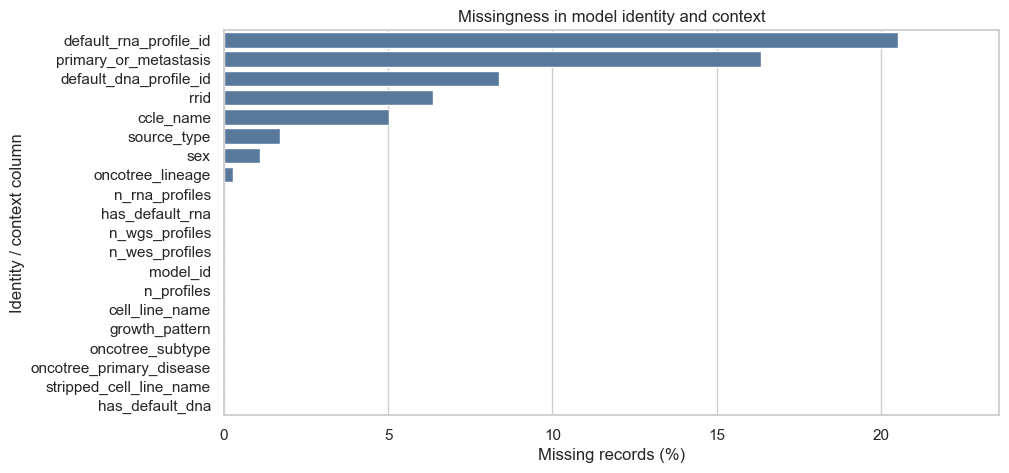

,identifier,non_null_n,duplicated_rows_n,duplicated_values_n
0,stripped_cell_line_name,2105,2,1
1,ccle_name,1999,0,0
2,rrid,1971,8,4


#### Records sharing `stripped_cell_line_name`

,model_id,stripped_cell_line_name,cell_line_name,oncotree_lineage
1085,ACH-001131,MS1,MS-1,Skin
1490,ACH-001958,MS1,MS1,Lung


#### Records sharing `rrid`

,model_id,rrid,cell_line_name,oncotree_lineage
829,ACH-000833,CVCL_0041,RH-30,Soft Tissue
1111,ACH-001189,CVCL_0041,SJRH-30,Soft Tissue
1012,ACH-001024,CVCL_1122,CHL-1,Skin
1025,ACH-001041,CVCL_1122,CHL-1-DM,Skin
1435,ACH-001737,CVCL_1150,CTV-1-DM,Lymphoid
1709,ACH-002222,CVCL_1150,CTV-1,Lymphoid
1339,ACH-001571,CVCL_1439,Mo,Lymphoid
1819,ACH-002339,CVCL_1439,MOT,Lymphoid


In [6]:
identity_columns = spine.columns.tolist()
missingness = (
    master[identity_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('missing_pct')
    .to_frame()
)
missingness['missing_n'] = master[identity_columns].isna().sum()
display(missingness)

plt.figure(figsize=(10, 5))
sns.barplot(data=missingness.reset_index(), x='missing_pct', y='index', color='#4C78A8')
plt.xlabel('Missing records (%)')
plt.ylabel('Identity / context column')
plt.title('Missingness in model identity and context')
plt.xlim(0, max(5, missingness['missing_pct'].max() * 1.15))
plt.show()

name_keys = ['stripped_cell_line_name', 'ccle_name', 'rrid']
collision_rows = []
for key in name_keys:
    duplicate_values = master.loc[master[key].notna() & master[key].duplicated(keep=False), ['model_id', key, 'cell_line_name', 'oncotree_lineage']]
    collision_rows.append({'identifier': key, 'non_null_n': master[key].notna().sum(), 'duplicated_rows_n': len(duplicate_values), 'duplicated_values_n': duplicate_values[key].nunique()})
display(pd.DataFrame(collision_rows))

for key in name_keys:
    review = master.loc[master[key].notna() & master[key].duplicated(keep=False), ['model_id', key, 'cell_line_name', 'oncotree_lineage']].sort_values(key)
    if not review.empty:
        display(Markdown(f'#### Records sharing `{key}`'))
        display(review)

### Why this EDA check matters

Names such as `cell_line_name`, `ccle_name`, and `rrid` are useful for people, but they are not equally complete or guaranteed to be unique. Missing context can also prevent a model from being placed in the correct biological subgroup.

**Example:** two laboratories may format the same name differently (`NIH:OVCAR-3` versus `NIHOVCAR3`). Joining by name could miss or duplicate it. `model_id` avoids that ambiguity; names and RRIDs are used only to review questionable records.

## 4. Biological and experimental context

Cancer lineage is a major confounder. A gene may appear coexpressed or coessential across all models simply because both signals are common in one lineage. We therefore inspect the usable sample sizes before deciding which strata are suitable for pair-level analyses.

#### oncotree_lineage

,oncotree_lineage,models
0,Lung,260
1,Lymphoid,260
2,Skin,149
3,CNS/Brain,125
4,Esophagus/Stomach,103
5,Bowel,99
6,Breast,96
7,Head and Neck,95
8,Bone,90
9,Myeloid,88


#### oncotree_primary_disease

,oncotree_primary_disease,models
0,Non-Small Cell Lung Cancer,164
1,Non-Cancerous,137
2,Melanoma,134
3,Mature B-Cell Neoplasms,131
4,Diffuse Glioma,97
5,Colorectal Adenocarcinoma,96
6,Head and Neck Squamous Cell Carcinoma,90
7,Lung Neuroendocrine Tumor,85
8,Invasive Breast Carcinoma,82
9,Esophagogastric Adenocarcinoma,74


#### oncotree_subtype

...

,primary_or_metastasis,models
0,Primary,1121
1,Metastatic,620
2,Missing,344
3,Unknown,19
4,Recurrent,1


#### source_type

,source_type,models
0,Academic lab,561
1,ATCC,528
2,DSMZ,319
3,HSRRB,113
4,RIKEN,110
5,KCLB,81
6,Sigma-Aldrich,75
7,CCLF,71
8,JCRB,66
9,ECACC,60


#### growth_pattern

,growth_pattern,models
0,Adherent,1387
1,Suspension,430
2,Unknown,155
3,Mixed,108
4,Dome,24
5,Spheroid,1


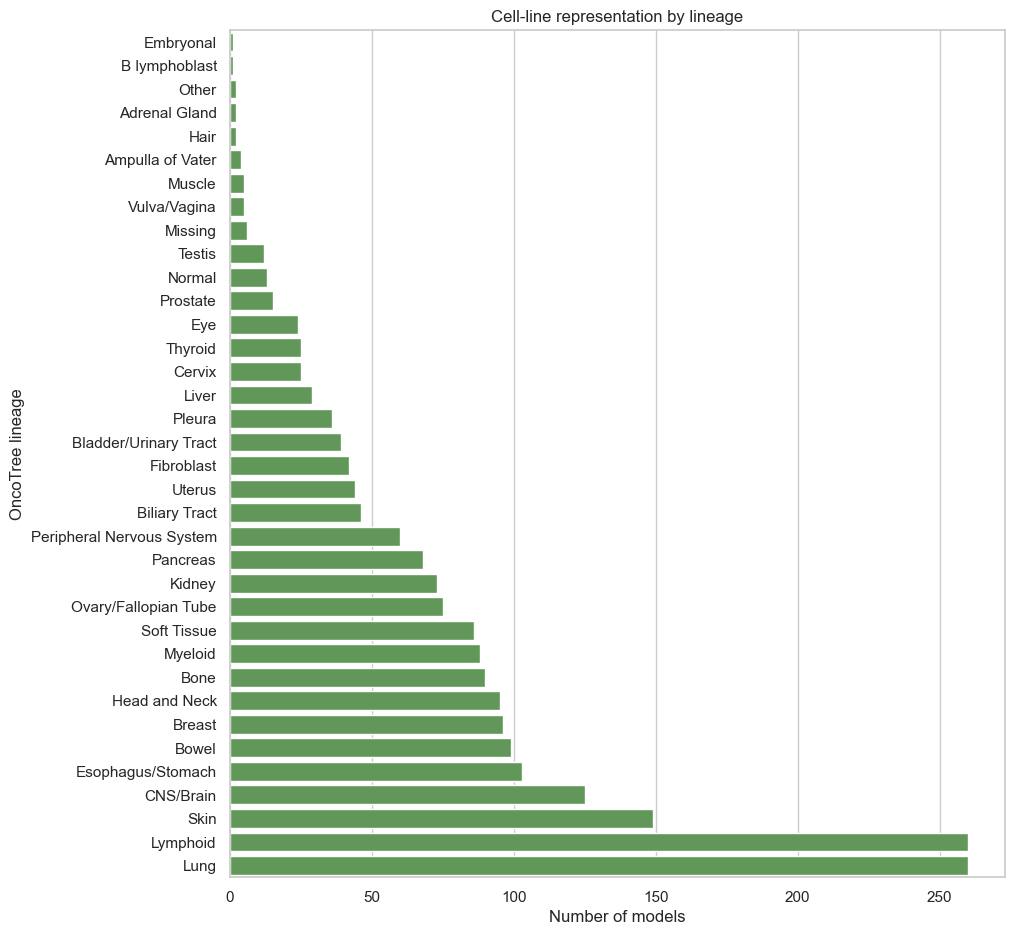

#### Lineages with fewer than 20 models

,models
oncotree_lineage,
Embryonal,1
B lymphoblast,1
Other,2
Adrenal Gland,2
Hair,2
Ampulla of Vater,4
Muscle,5
Vulva/Vagina,5
Missing,6


In [7]:
context_columns = ['oncotree_lineage', 'oncotree_primary_disease', 'oncotree_subtype', 'sex', 'primary_or_metastasis', 'source_type', 'growth_pattern']
for column in context_columns:
    summary = master[column].fillna('Missing').value_counts(dropna=False).rename_axis(column).reset_index(name='models')
    display(Markdown(f'#### {column}'))
    display(summary.head(25))

lineage_counts = master['oncotree_lineage'].fillna('Missing').value_counts().sort_values(ascending=True)
plt.figure(figsize=(10, 11))
sns.barplot(x=lineage_counts.values, y=lineage_counts.index, color='#59A14F')
plt.xlabel('Number of models')
plt.ylabel('OncoTree lineage')
plt.title('Cell-line representation by lineage')
plt.show()

small_lineages = lineage_counts[lineage_counts < 20].rename('models').to_frame()
display(Markdown('#### Lineages with fewer than 20 models'))
display(small_lineages)

### Why this EDA check matters

A **model** is one cell-line experiment unit. Its biological context says what cancer it represents; its experimental context says how it was grown and what was measured. `oncotree_lineage` is broad (for example, Lung), `oncotree_primary_disease` is more specific (Non-Small Cell Lung Cancer), and `oncotree_subtype` can be more specific again (Lung Adenocarcinoma).

**Example:** a gene may be highly expressed in lung models and weakly expressed in leukemia models. A pooled correlation between two genes might then be driven by the lung-versus-leukemia difference, not by a relationship inside either cancer type. Looking at lineage counts tells us when to stratify the analysis and when a group is too small to interpret reliably.

## 5. Profile depth and default-profile logic

A model can have multiple RNA or DNA profiles. Pair-scoring should normally use the selected default profile rather than treating technical or condition-specific profiles as independent cell lines.

,count,mean,std,min,25%,50%,75%,max
n_profiles,2105.0,2.146318,0.944499,0.0,2.0,2.0,3.0,5.0
n_rna_profiles,2105.0,0.802850,0.417752,0.0,1.0,1.0,1.0,2.0
n_wes_profiles,2105.0,0.906888,0.532120,0.0,1.0,1.0,1.0,2.0
n_wgs_profiles,2105.0,0.436580,0.497992,0.0,0.0,0.0,1.0,2.0
n_model_conditions,2105.0,1.313064,0.556969,0.0,1.0,1.0,2.0,3.0
n_crispr_screens,2105.0,0.665558,0.664325,0.0,0.0,1.0,1.0,3.0


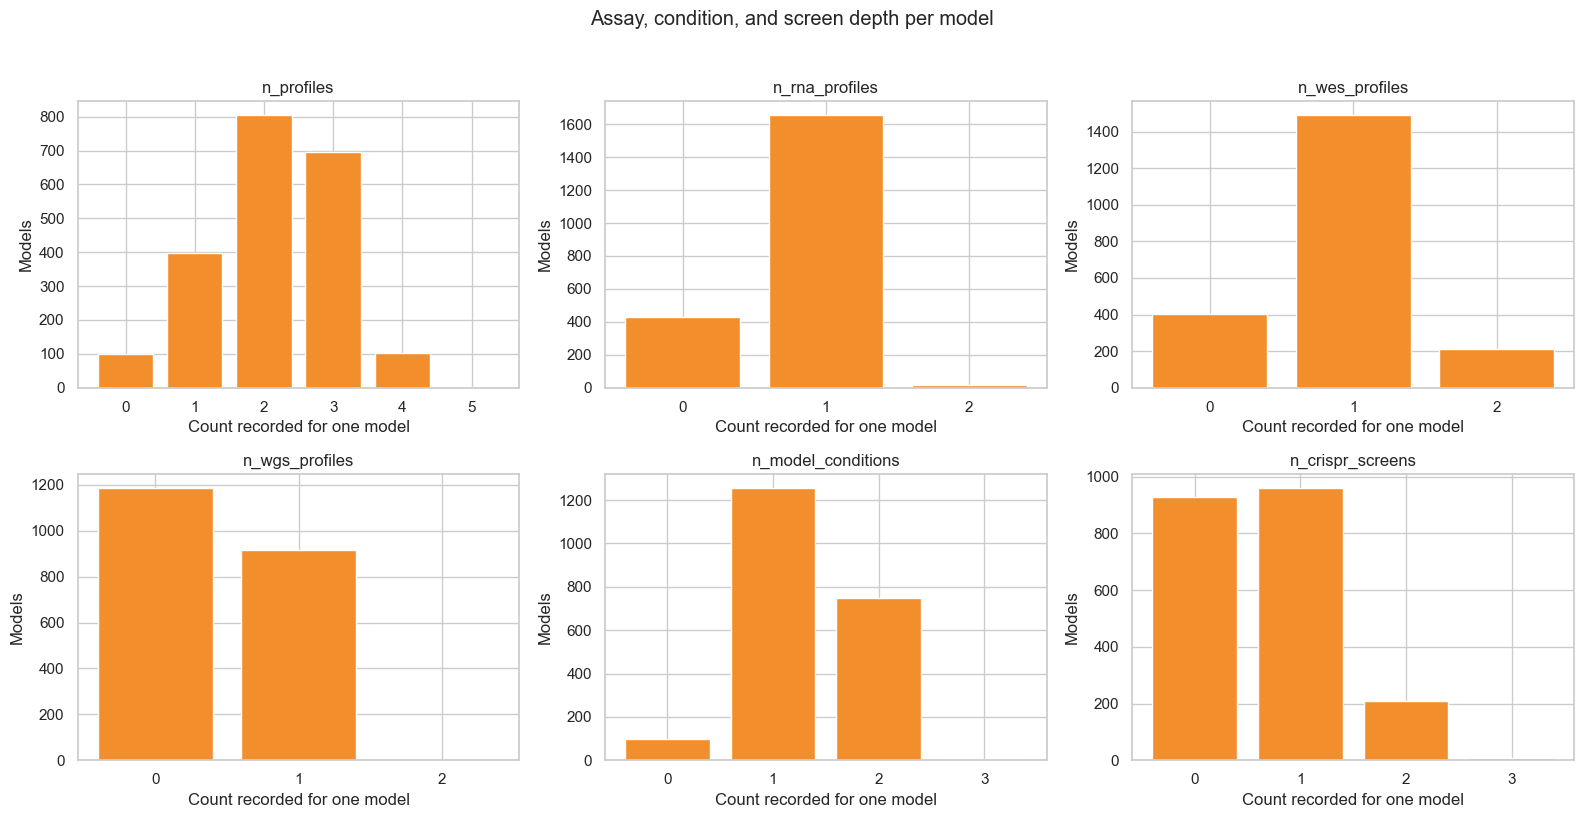

,check,models_failing
0,has_default_rna differs from non-null default_...,0
1,has_default_dna differs from non-null default_...,0
2,has_default_rna is 1 when n_rna_profiles is 0,0
3,has_default_dna is 1 when n_wes_profiles + n_w...,0


In [8]:
profile_columns = ['n_profiles', 'n_rna_profiles', 'n_wes_profiles', 'n_wgs_profiles', 'n_model_conditions', 'n_crispr_screens']
profile_summary = master[profile_columns].describe().T
display(profile_summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, column in zip(axes.flat, profile_columns):
    counts = master[column].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='#F28E2B')
    ax.set_title(column)
    ax.set_xlabel('Count recorded for one model')
    ax.set_ylabel('Models')
plt.suptitle('Assay, condition, and screen depth per model', y=1.02)
plt.tight_layout()
plt.show()

default_profile_checks = pd.DataFrame({
    'check': [
        'has_default_rna differs from non-null default_rna_profile_id',
        'has_default_dna differs from non-null default_dna_profile_id',
        'has_default_rna is 1 when n_rna_profiles is 0',
        'has_default_dna is 1 when n_wes_profiles + n_wgs_profiles is 0',
    ],
    'models_failing': [
        int((master['has_default_rna'].eq(1) != master['default_rna_profile_id'].notna()).sum()),
        int((master['has_default_dna'].eq(1) != master['default_dna_profile_id'].notna()).sum()),
        int((master['has_default_rna'].eq(1) & master['n_rna_profiles'].eq(0)).sum()),
        int((master['has_default_dna'].eq(1) & (master['n_wes_profiles'] + master['n_wgs_profiles']).eq(0)).sum()),
    ],
})
display(default_profile_checks)

### Why this EDA check matters

One biological model can have more than one RNA, DNA, condition, or CRISPR profile. Those profiles are repeated measurements of the same model, not separate patients or separate cell lines.

**Example:** if a model has two RNA profiles and both are analysed as separate rows, its gene-expression pattern receives twice the influence of a model with one profile. Using the selected default profile keeps each `model_id` represented once and makes model-to-model comparisons fair.

## 6. Assay coverage and route eligibility

This is the central denominator audit. We compare availability across all models and then by lineage. A feature can only be interpreted within the models that were actually measured for the underlying assays.

,available_models,coverage_pct
has_model_condition,2009,95.44
has_genomic_signatures,1929,91.64
has_any_mutation_event,1929,91.64
has_mutation_assay,1929,91.64
has_expression,1673,79.48
has_fusion_assay,1672,79.43
eligible_direct_fusion_route,1672,79.43
has_any_filtered_fusion_call,1670,79.33
has_absolute_copy_number,1607,76.34
has_crispr_gene_effect,1178,55.96


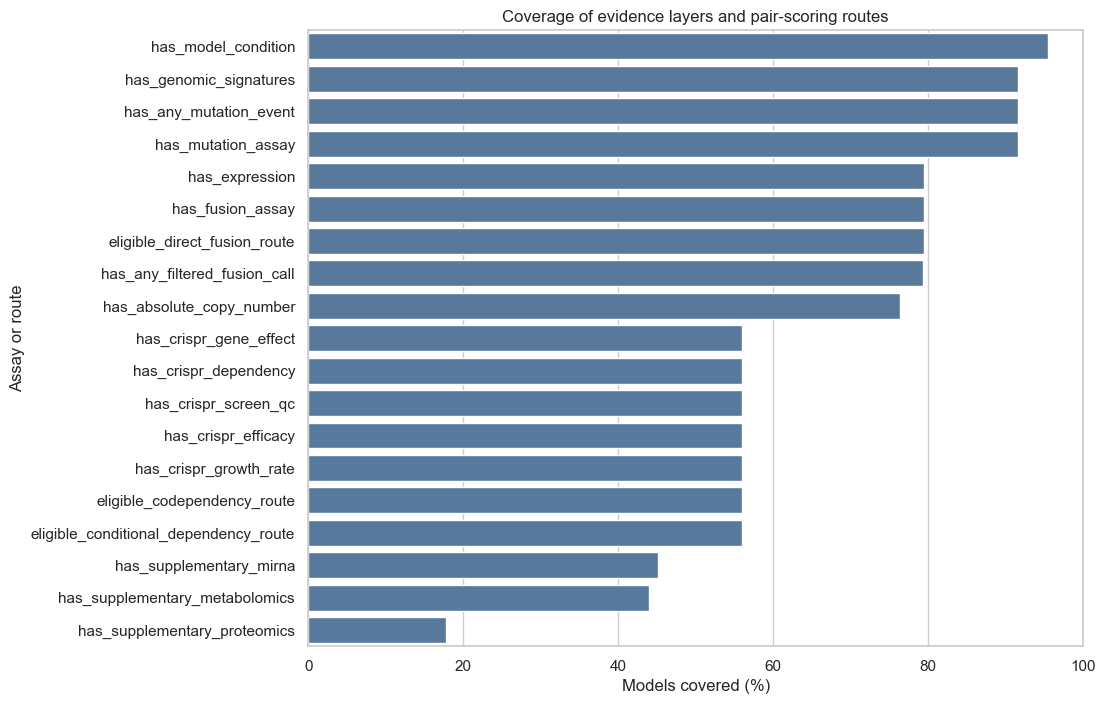

#### Route overlap: values are `1` when a model is eligible

,fusion | codependency | conditional,models
0,1 | 1 | 1,1102
1,1 | 0 | 0,570
2,0 | 0 | 0,357
3,0 | 1 | 1,76


In [9]:
assay_flags = [
    'has_expression', 'has_mutation_assay', 'has_any_mutation_event',
    'has_fusion_assay', 'has_any_filtered_fusion_call', 'has_genomic_signatures',
    'has_crispr_gene_effect', 'has_crispr_dependency', 'has_absolute_copy_number',
    'has_model_condition', 'has_crispr_screen_qc', 'has_crispr_efficacy',
    'has_crispr_growth_rate', 'has_supplementary_metabolomics',
    'has_supplementary_proteomics', 'has_supplementary_mirna',
]
route_flags = ['eligible_direct_fusion_route', 'eligible_codependency_route', 'eligible_conditional_dependency_route']

coverage = pd.DataFrame({
    'available_models': master[assay_flags + route_flags].sum(),
    'coverage_pct': (100 * master[assay_flags + route_flags].mean()).round(2),
}).sort_values('coverage_pct', ascending=False)
display(coverage)

plt.figure(figsize=(10, 8))
sns.barplot(data=coverage.reset_index(), x='coverage_pct', y='index', color='#4C78A8')
plt.xlabel('Models covered (%)')
plt.ylabel('Assay or route')
plt.title('Coverage of evidence layers and pair-scoring routes')
plt.xlim(0, 100)
plt.show()

route_combinations = (
    master[route_flags].astype(int).astype(str).agg(' | '.join, axis=1)
    .value_counts()
    .rename_axis('fusion | codependency | conditional')
    .reset_index(name='models')
)
display(Markdown('#### Route overlap: values are `1` when a model is eligible'))
display(route_combinations)

,has_expression,has_mutation_assay,has_any_mutation_event,has_fusion_assay,has_any_filtered_fusion_call,has_genomic_signatures,has_crispr_gene_effect,has_crispr_dependency,has_absolute_copy_number,has_model_condition,has_crispr_screen_qc,has_crispr_efficacy,has_crispr_growth_rate,has_supplementary_metabolomics,has_supplementary_proteomics,has_supplementary_mirna,eligible_direct_fusion_route,eligible_codependency_route,eligible_conditional_dependency_route,all_models
oncotree_lineage,,,,,,,,,,,,,,,,,,,,
Lung,82.3,91.2,91.2,82.3,82.3,91.2,48.5,48.5,75.4,96.5,48.5,48.5,48.5,65.8,29.2,64.6,82.3,48.5,48.5,260
Lymphoid,71.5,96.9,96.9,71.5,71.5,96.9,35.8,35.8,84.6,98.5,35.8,35.8,35.8,43.5,9.2,45.0,71.5,35.8,35.8,260
Skin,80.5,94.0,94.0,80.5,80.5,94.0,49.7,49.7,81.9,95.3,49.7,49.7,49.7,34.2,22.1,33.6,80.5,49.7,49.7,149
CNS/Brain,80.0,90.4,90.4,80.0,79.2,90.4,72.0,72.0,75.2,96.0,72.0,72.0,72.0,40.0,11.2,39.2,80.0,72.0,72.0,125
Esophagus/Stomach,74.8,87.4,87.4,74.8,74.8,87.4,67.0,67.0,73.8,87.4,67.0,67.0,67.0,61.2,27.2,60.2,74.8,67.0,67.0,103
Bowel,86.9,91.9,91.9,86.9,86.9,91.9,63.6,63.6,72.7,93.9,63.6,63.6,63.6,56.6,30.3,57.6,86.9,63.6,63.6,99
Breast,72.9,78.1,78.1,72.9,72.9,78.1,55.2,55.2,59.4,79.2,55.2,55.2,55.2,50.0,31.2,52.1,72.9,55.2,55.2,96
Head and Neck,77.9,98.9,98.9,77.9,77.9,98.9,81.1,81.1,88.4,98.9,81.1,81.1,81.1,35.8,10.5,36.8,77.9,81.1,81.1,95
Bone,61.1,93.3,93.3,61.1,61.1,93.3,51.1,51.1,76.7,94.4,51.1,51.1,51.1,17.8,7.8,17.8,61.1,51.1,51.1,90


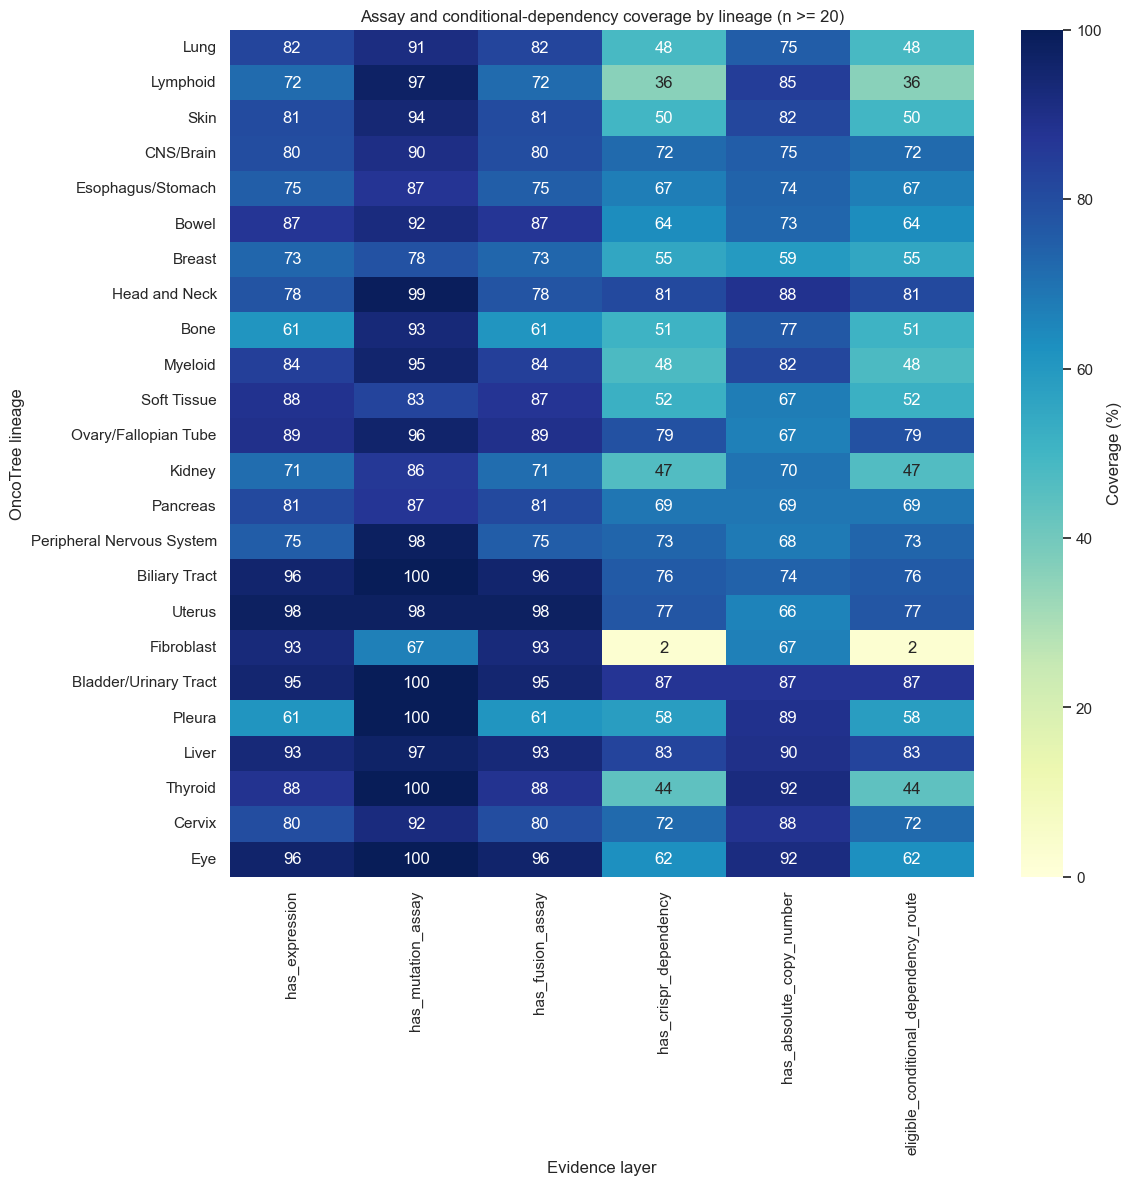

#### Coverage range across adequately sized lineages

,min,max,range_pct_points
has_crispr_dependency,2.4,87.2,84.8
eligible_conditional_dependency_route,2.4,87.2,84.8
has_expression,61.1,97.7,36.6
has_fusion_assay,61.1,97.7,36.6
has_mutation_assay,66.7,100.0,33.3
has_absolute_copy_number,59.4,92.0,32.6


In [10]:
lineage_sizes = master.groupby('oncotree_lineage', dropna=False).size().rename('all_models')
lineage_coverage = master.groupby('oncotree_lineage', dropna=False)[assay_flags + route_flags].mean().mul(100)
lineage_coverage = lineage_coverage.join(lineage_sizes).sort_values('all_models', ascending=False)
display(lineage_coverage.round(1))

plot_flags = ['has_expression', 'has_mutation_assay', 'has_fusion_assay', 'has_crispr_dependency', 'has_absolute_copy_number', 'eligible_conditional_dependency_route']
large_lineages = lineage_coverage.query('all_models >= 20').index
plt.figure(figsize=(12, 11))
sns.heatmap(lineage_coverage.loc[large_lineages, plot_flags], cmap='YlGnBu', vmin=0, vmax=100, annot=True, fmt='.0f', cbar_kws={'label': 'Coverage (%)'})
plt.title('Assay and conditional-dependency coverage by lineage (n >= 20)')
plt.xlabel('Evidence layer')
plt.ylabel('OncoTree lineage')
plt.show()

coverage_gap = lineage_coverage.loc[large_lineages, plot_flags].agg(['min', 'max']).T
coverage_gap['range_pct_points'] = coverage_gap['max'] - coverage_gap['min']
display(Markdown('#### Coverage range across adequately sized lineages'))
display(coverage_gap.sort_values('range_pct_points', ascending=False).round(1))

### Why this EDA check matters

Every downstream question has its own valid denominator: only models with the necessary assays can contribute. A route flag means the inputs are available; it does **not** claim that a fusion, mutation, or gene dependency is present.

**Example:** direct-fusion analysis can use 1,672 eligible models, whereas CRISPR codependency can use 1,178. Treating the remaining models as negative for a CRISPR dependency would be wrong—they were not measured in that assay. The lineage heatmap also reveals when availability differs by cancer type and could bias a pooled result.

## 7. Readiness summaries for later feature engineering

These are not prediction features. They are transparent cohort definitions that will be carried forward into mutation, fusion, RNA, and CRISPR EDA.

In [11]:
master = master.copy()
master['identity_complete_for_stratification'] = master[['oncotree_lineage', 'oncotree_primary_disease', 'oncotree_subtype']].notna().all(axis=1)
master['core_pair_evidence_ready'] = master[['has_expression', 'has_crispr_gene_effect', 'has_crispr_dependency']].eq(1).all(axis=1)
master['conditional_dependency_ready'] = master['eligible_conditional_dependency_route'].eq(1)
master['fusion_ready'] = master['eligible_direct_fusion_route'].eq(1)

readiness_columns = ['identity_complete_for_stratification', 'core_pair_evidence_ready', 'conditional_dependency_ready', 'fusion_ready']
readiness = pd.DataFrame({
    'models': master[readiness_columns].sum(),
    'pct_of_master': (100 * master[readiness_columns].mean()).round(2),
})
display(readiness)

lineage_readiness = (
    master.groupby('oncotree_lineage', dropna=False)[readiness_columns]
    .mean()
    .mul(100)
    .join(lineage_sizes)
    .sort_values('all_models', ascending=False)
)
display(lineage_readiness.round(1))

review_columns = ['model_id', 'cell_line_name', 'oncotree_lineage', 'oncotree_primary_disease', 'primary_or_metastasis', 'ccle_name', 'rrid']
review_queue = master.loc[~master['identity_complete_for_stratification'], review_columns].copy()
display(Markdown('#### Records needing identity/context review before fine-grained stratification'))
display(review_queue)

,models,pct_of_master
identity_complete_for_stratification,2099,99.71
core_pair_evidence_ready,1103,52.40
conditional_dependency_ready,1178,55.96
fusion_ready,1672,79.43


,identity_complete_for_stratification,core_pair_evidence_ready,conditional_dependency_ready,fusion_ready,all_models
oncotree_lineage,,,,,
Lung,100.0,47.3,48.5,82.3,260
Lymphoid,100.0,35.0,35.8,71.5,260
Skin,100.0,49.0,49.7,80.5,149
CNS/Brain,100.0,65.6,72.0,80.0,125
Esophagus/Stomach,100.0,60.2,67.0,74.8,103
Bowel,100.0,59.6,63.6,86.9,99
Breast,100.0,52.1,55.2,72.9,96
Head and Neck,100.0,64.2,81.1,77.9,95
Bone,100.0,38.9,51.1,61.1,90


#### Records needing identity/context review before fine-grained stratification

,model_id,cell_line_name,oncotree_lineage,oncotree_primary_disease,primary_or_metastasis,ccle_name,rrid
2040,ACH-003132,ABM-T0009,NaN,Non-Cancerous,NaN,NaN,NaN
2041,ACH-003133,ABM-T0021,NaN,Non-Cancerous,NaN,NaN,NaN
2042,ACH-003134,ABM-T0168,NaN,Non-Cancerous,NaN,NaN,NaN
2044,ACH-003136,ABM-T0023,NaN,Non-Cancerous,NaN,NaN,NaN
2052,ACH-003147,ABM-T0732,NaN,Non-Cancerous,NaN,NaN,NaN
2078,ACH-003308,THLE-3,NaN,Non-Cancerous,Primary,NaN,CVCL_3804


### Why this EDA check matters

Readiness columns turn the availability checks into clear, reusable analysis cohorts. They make the inclusion rule visible instead of letting each later notebook choose rows implicitly.

**Example:** a conditional-dependency test needs an eligible CRISPR model, so it starts with 1,178 `conditional_dependency_ready` models—not all 2,105 models. Reporting this denominator helps readers judge the strength and generalisability of the result.

## Decisions carried into the next notebooks

- Use `model_id` as the only automatic model-level join key. Normalised names, CCLE names, and RRIDs are cross-checks, not replacements.
- Report every gene-pair statistic with its actual model denominator and assay-coverage rule.
- Stratify or adjust by `oncotree_lineage` before interpreting RNA correlation or CRISPR codependency. Do not pool tiny lineages.
- Use selected default profiles for RNA/DNA profile-keyed tables. Do not count multiple profiles as independent cell lines.
- Treat assay absence as missing evidence, never as a biological zero.
- Treat route eligibility as a cohort-definition/QC concept, never as evidence that a gene pair is biologically valid.

**Next notebook:** mutation and alteration EDA. It will use the `conditional_dependency_ready` cohort and create explicit, auditable definitions for a damaging alteration before testing whether alteration of gene A changes dependency on gene B.